In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer

from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:0'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
}

In [ ]:
paths = [
    'runs/newbase/dim64_seed0/model_weights.pth',
    'runs/newbase/dim64_seed42/model_weights.pth',
    'runs/newbase/dim64_seed123/model_weights.pth',
]

num_batches = 5
preds = [
    [[] for _ in range(7)] 
    for _ in range(len(paths))
]
targets = [
    [[] for _ in range(7)] 
    for _ in range(len(paths))
]
models = []

for path in paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()
    models.append(model)

for i, key in enumerate(data_keys):
    batch_count = 0
    for batch in dataloaders['validation'][key]:
        batch_count += 1
        img, target, _, pupil = batch
        
        for j, model in enumerate(models):
            with torch.no_grad():
                pred = model(img, data_key=key, pupil_center=pupil).cpu()
                preds[j][i].append(pred)
            targets[j][i].append(target.cpu())
        
        if batch_count == num_batches:
            break

for i in range(3):
    for j in range(7):
        preds[i][j] = torch.cat(preds[i][j])
        targets[i][j] = torch.cat(targets[i][j])
    # preds[i] = torch.cat(preds[i], dim=1)
    # targets[i] = torch.cat(targets[i], dim=1)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


# Neuron correlation across images

In [9]:
neuron_corrs = []

for i in range(3):
    model_corrs = []
    for j in range(7):
        X = preds[i][j]
        Y = targets[i][j]

        corr = torch.nn.functional.cosine_similarity(
            X - X.mean(0, keepdim=True),
            Y - Y.mean(0, keepdim=True),
            dim=0
        )
        model_corrs.append(corr)
    neuron_corrs.append(torch.cat(model_corrs))

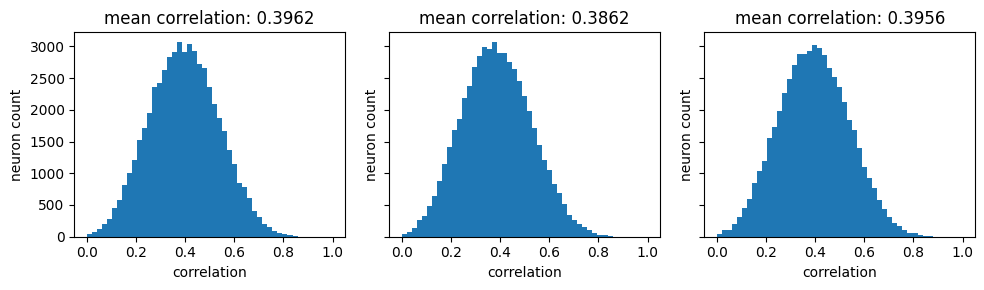

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey='row')
bins = torch.linspace(0, 1, 50)

for ax, corr in zip(axs, neuron_corrs):
    ax.hist(corr, bins=bins)
    ax.set_ylabel('neuron count')
    ax.set_xlabel('correlation')
    ax.set_title(f'mean correlation: {corr.mean():.4}')

plt.tight_layout()
plt.show()

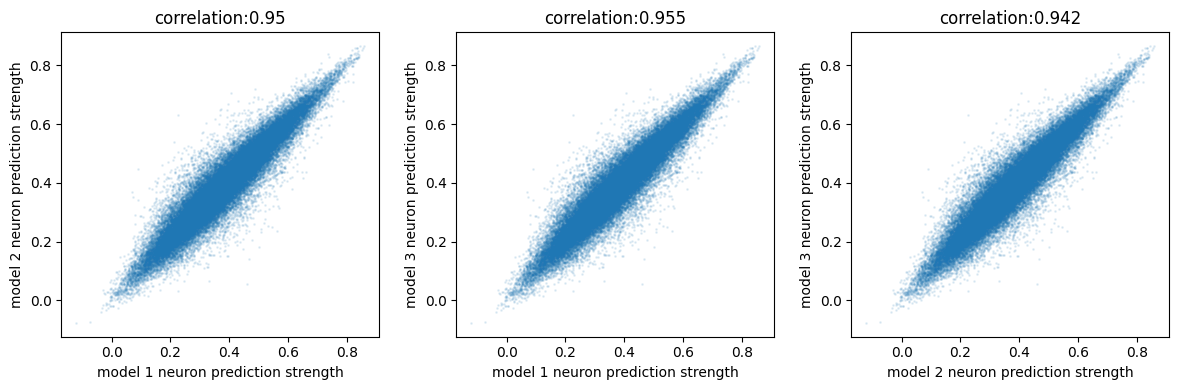

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for ax, (i, j) in zip(axs, [[0, 1], [0, 2], [1, 2]]):
    r = torch.corrcoef(torch.stack([neuron_corrs[i], neuron_corrs[j]]))[0, 1]

    ax.scatter(torch.stack(corrs)[1], torch.stack(corrs)[2], alpha=0.1, s=1)
    ax.axis('equal')
    ax.set_xlabel(f'model {i+1} neuron prediction strength')
    ax.set_ylabel(f'model {j+1} neuron prediction strength')
    ax.set_title(f'correlation:{r.item():.3}')

plt.tight_layout()
plt.show()

# Image correlation across neurons

In [14]:
image_corrs = []

for i in range(3):
    model_corrs = []
    for j in range(7):
        X = preds[i][j].T
        Y = targets[i][j].T

        corr = torch.nn.functional.cosine_similarity(
            X - X.mean(0, keepdim=True),
            Y - Y.mean(0, keepdim=True),
            dim=0
        )
        model_corrs.append(corr)
    image_corrs.append(torch.cat(model_corrs))

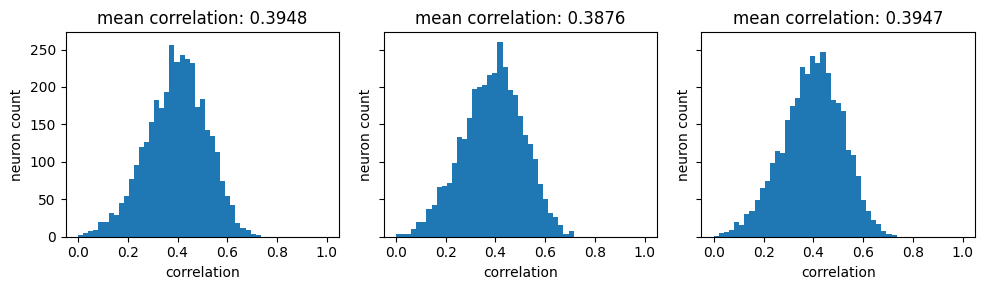

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey='row')
bins = torch.linspace(0, 1, 50)

for ax, corr in zip(axs, image_corrs):
    ax.hist(corr, bins=bins)
    ax.set_ylabel('neuron count')
    ax.set_xlabel('correlation')
    ax.set_title(f'mean correlation: {corr.mean():.4}')

plt.tight_layout()
plt.show()

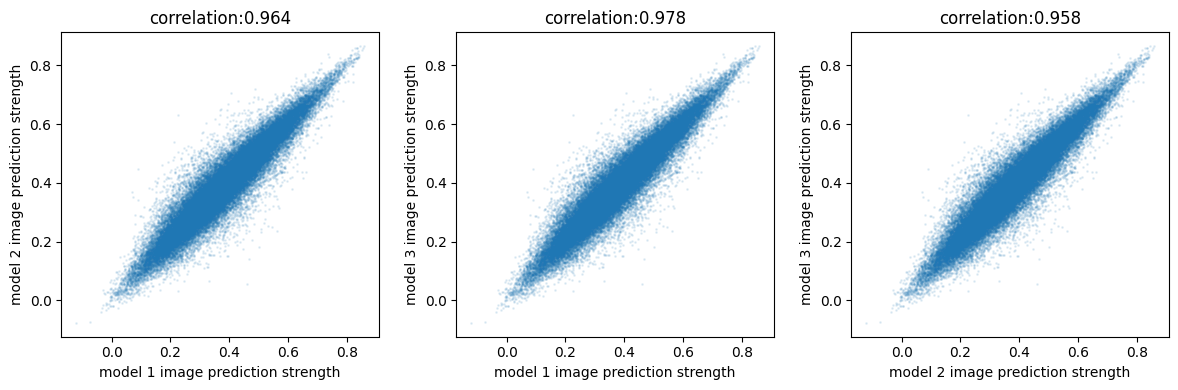

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for ax, (i, j) in zip(axs, [[0, 1], [0, 2], [1, 2]]):
    r = torch.corrcoef(torch.stack([image_corrs[i], image_corrs[j]]))[0, 1]

    ax.scatter(torch.stack(corrs)[1], torch.stack(corrs)[2], alpha=0.1, s=1)
    ax.axis('equal')
    ax.set_xlabel(f'model {i+1} image prediction strength')
    ax.set_ylabel(f'model {j+1} image prediction strength')
    ax.set_title(f'correlation:{r.item():.3}')

plt.tight_layout()
plt.show()

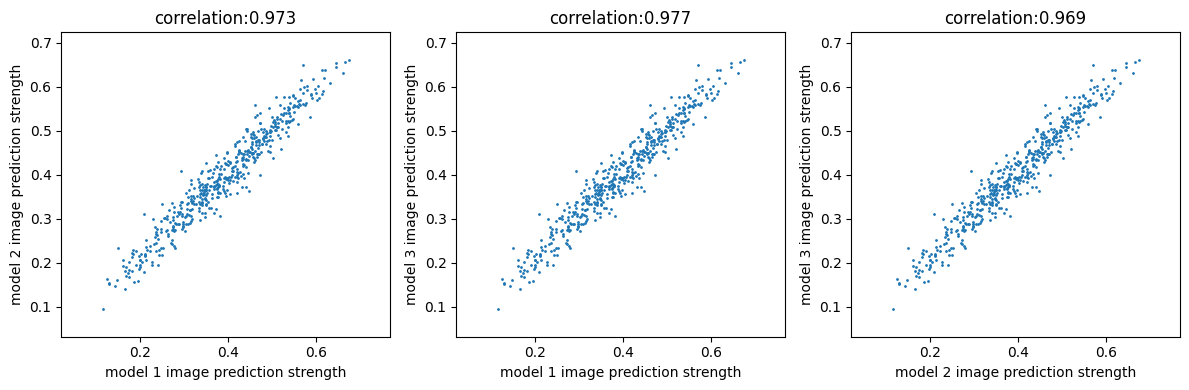

In [43]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for ax, (i, j) in zip(axs, [[0, 1], [0, 2], [1, 2]]):
    r = torch.corrcoef(torch.stack([corrs[i], corrs[j]]))[0, 1]

    ax.scatter(torch.stack(corrs)[1], torch.stack(corrs)[2], alpha=1, s=1)
    ax.axis('equal')
    ax.set_xlabel(f'model {i+1} image prediction strength')
    ax.set_ylabel(f'model {j+1} image prediction strength')
    ax.set_title(f'correlation:{r.item():.3}')
plt.tight_layout()
plt.show()

In [3]:
paths = [
    'runs/newbase/dim64_seed0/model_weights.pth',
    'runs/newbase/dim64_seed42/model_weights.pth',
    'runs/newbase/dim64_seed123/model_weights.pth',
]

num_batches = 3
preds = [
    [[] for _ in range(7)] 
    for _ in range(len(paths))
]
targets = [
    [[] for _ in range(7)] 
    for _ in range(len(paths))
]
models = []

for path in paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()
    models.append(model)

for i, key in enumerate(data_keys):
    batch_count = 0
    for batch in dataloaders['validation'][key]:
        batch_count += 1
        img, target, _, pupil = batch
        
        for j, model in enumerate(models):
            with torch.no_grad():
                pred = model(img, data_key=key, pupil_center=pupil).cpu()
                preds[j][i].append(pred)
            targets[j][i].append(target.cpu())
        
        if batch_count == num_batches:
            break

for i in range(3):
    for j in range(7):
        preds[i][j] = torch.cat(preds[i][j])
        targets[i][j] = torch.cat(targets[i][j])
    preds[i] = torch.cat(preds[i], dim=1)
    targets[i] = torch.cat(targets[i], dim=1)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


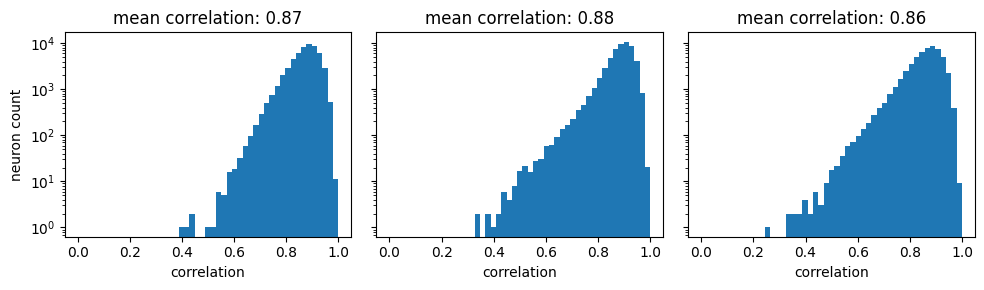

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey='row')
bins = torch.linspace(0, 1, 50)

X = preds[0]#[:, mask0 & mask1]
Y = preds[1]#[:, mask0 & mask1]
corr = torch.nn.functional.cosine_similarity(
    X - X.mean(0, keepdim=True),
    Y - Y.mean(0, keepdim=True),
    dim=0
)
axs[0].hist(corr, bins=bins)
axs[0].set_ylabel('neuron count')
axs[0].set_xlabel('correlation')
axs[0].set_yscale('log')
axs[0].set_title(f'mean correlation: {corr.mean():.2}')

X = preds[0]#[:, mask0 & mask2]
Y = preds[2]#[:, mask0 & mask2]
corr = torch.nn.functional.cosine_similarity(
    X - X.mean(0, keepdim=True),
    Y - Y.mean(0, keepdim=True),
    dim=0
)
axs[1].hist(corr, bins=bins)
axs[1].set_xlabel('correlation')
axs[1].set_title(f'mean correlation: {corr.mean():.2}')

X = preds[1]#[:, mask1 & mask2]
Y = preds[2]#[:, mask1 & mask2]
corr = torch.nn.functional.cosine_similarity(
    X - X.mean(0, keepdim=True),
    Y - Y.mean(0, keepdim=True),
    dim=0
)
axs[2].hist(corr, bins=bins)
axs[2].set_xlabel('correlation')
axs[2].set_yscale('log')
axs[2].set_title(f'mean correlation: {corr.mean():.2}')

plt.tight_layout()
plt.show()

In [17]:
paths = [
    'runs/newbase/dim64_seed0/model_weights.pth',
    'runs/newbase/dim64_seed42/model_weights.pth',
    'runs/newbase/dim64_seed123/model_weights.pth',
]

num_batches = 3

key = data_keys[0]
vecs = [[] for _ in range(len(paths))]

models = []

for path in paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.train()
    models.append(model)

batch_count = 0
for batch in dataloaders['validation'][key]:
    batch_count += 1
    img, target, _, pupil = batch
    
    for j, model in enumerate(models):
        with torch.no_grad():
            pred, vec = model(img, data_key=key, pupil_center=pupil, return_vec=True)
            vecs[j].append(vec.cpu())
    
    if batch_count == num_batches:
        break

for i in range(3):
    vecs[i] = torch.cat(vecs[i], dim=0).transpose(1, 3).flatten(0, 2)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [65]:
from sklearn.cross_decomposition import CCA
n = 4000
idcs = torch.randperm(vecs[0].shape[0])[:n]
X = np.ascontiguousarray(vecs[0][idcs], dtype=np.float64)
Y = np.ascontiguousarray(vecs[1][idcs], dtype=np.float64)
print('0')
cca = CCA(n_components=64)
print('1')
Xc, Yc = cca.fit_transform(X, Y)

0
1


/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


In [60]:
corrs = [
    np.corrcoef(Xc[:, i], Yc[:, i])[0, 1]
    for i in range(Xc.shape[1])
]

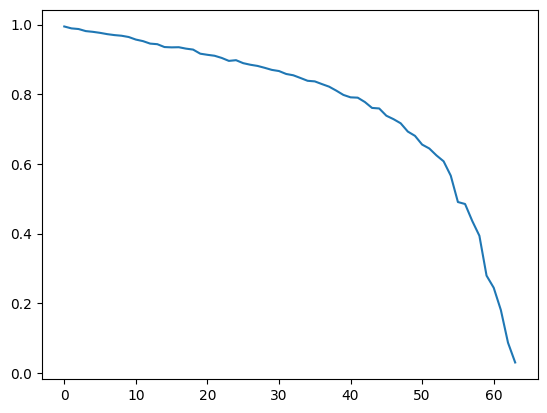

In [61]:
plt.plot(corrs)
plt.show()